In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import cumulative_trapezoid
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

In [28]:
def vector_cosine(vector1, vector2):
    vector1 = np.asarray(vector1)
    vector2 = np.asarray(vector2)
    scalar_input = False
    if vector1.ndim == 1:
        vector1 = vector1[None]  # Makes vector1 2D
        vector2 = vector2[None]  # Makes vector2 2D
        scalar_input = True

    ret = np.zeros(len(vector1))
    for i, (v1, v2) in enumerate(zip(vector1, vector2)):
        ret[i] = np.dot(v1, v2) / np.linalg.norm(v1) / np.linalg.norm(v2)

    if scalar_input:
        return np.squeeze(ret)
    return ret 

def get_rc_force(frc, pos):
    r1 = np.linalg.norm(pos[0] - pos[1])
    r2 = np.linalg.norm(pos[2] - pos[1])
    f1 = np.dot(frc[0] - frc[1], pos[0] - pos[1]) / r1 
    f2 = np.dot(frc[2] - frc[1], pos[2] - pos[1]) / r2
    cosa = vector_cosine(pos[0] - pos[1], pos[2] - pos[1])
    # return (f1 - f2) / (4 - 2 * cosa), r1 - r2
    return (f1 - f2) / (4 - 2 * cosa), r2 - r1

# def get_rc_force(frc, pos):
#     """Calculate the reaction coordinate force and reaction coordinate value"""
#     r1 = np.linalg.norm(pos[2] - pos[3])
#     r2 = np.linalg.norm(pos[0] - pos[1])
#     f1 = np.dot(frc[2] - frc[3], pos[2] - pos[3]) / r1
#     f2 = np.dot(frc[0] - frc[1], pos[0] - pos[1]) / r2
#     return (f2 - f1) / 4, r1 - r2


def get_pmf(forces, positions):
    """Calculate the potential of mean force"""
    if forces.shape != positions.shape:
        raise ValueError("forces and positions must have the same shape")
    rc_forces = np.zeros((forces.shape[0], forces.shape[1]))
    rc_values = np.zeros((forces.shape[0], forces.shape[1]))
    for i, (force, position) in enumerate(zip(forces, positions)):
        for j, (frc, pos) in enumerate(zip(force, position)):
            rc_forces[i, j], rc_values[i, j] = get_rc_force(frc, pos)
    mean_forces = rc_forces.mean(axis=1)
    mean_forces_var = rc_forces.var(axis=1) / rc_forces.shape[1]
    mean_rc = rc_values.mean(axis=1)
    return cumulative_trapezoid(mean_forces, mean_rc), np.sqrt(cumulative_trapezoid(mean_forces_var, mean_rc)), mean_rc


def get_barrier(forces, positions, rs_bin=None, ts_bin=None):
    """Calculate the free energy barrier"""
    pmf, pmf_std, _ = get_pmf(forces, positions)
    if rs_bin is None:
        rs_bin = np.argmin(pmf[:10])
    if ts_bin is None:
        ts_bin = np.argmax(pmf)
    barrier = pmf[ts_bin] - pmf[rs_bin]
    barrier_std = np.sqrt(pmf_std[ts_bin]**2 + pmf_std[rs_bin]**2)
    return barrier, barrier_std


def plot_pmf(force_list, position, labels=None, figure=None, **kwargs):
    """Plot the potential of mean force"""
    if labels is None:
        labels = ["" for _ in force_list]
    elif len(labels) != len(force_list):
        raise ValueError("labels must have the same length as force_list")

    # fig, ax = plt.subplots(figsize=(6,4, 6))
    plt.figure(figsize=(4.33,3), dpi=300)
    
    fig,ax = plt.subplots()

    ax.set_xlabel("Reaction Coordinate (Å)", size=13)
    ax.set_ylabel("Free Energy (kcal/mol)", size=13)
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))

    for force, label in zip(force_list, labels):
        pmf, pmf_std, rc = get_pmf(force, position)
        # ax.errorbar(rc[1:], pmf, yerr=pmf_std, linewidth=1, label=label, **kwargs)
        ax.plot(rc[1:], pmf, label=label, alpha=0.8, **kwargs)
        ax.fill_between(rc[1:], pmf-pmf_std, pmf+pmf_std, alpha=0.5, **kwargs)

    ax.legend(fontsize=12)
    fig.tight_layout()

    if figure is not None:
        fig.savefig(figure)

In [32]:
qm_pos = np.load("qm_pos.npy") # QM positions
res_names = np.load("res_names.npy") # Residue names

pcm_qm_forces = np.load("pcm_qm_forces.npy") # QM forces in PCM phase
gas_qm_forces = np.load("gas_qm_forces.npy") # QM forces in gas phase
gas_res_forces = np.load("gas_res_forces2.npy") # QM forces from the residues in gas phase (Permanent electrostatics)

qmmm_qm_forces = np.load("qmmm_qm_forces.npy") # QM forces in QM/MM
qmmm_res_forces = np.load("qmmm_res_forces2.npy") # QM forces from the residues in QM/MM)

vdw_res_forces = np.load("vdw_res_forces2.npy") # QM forces from the residues in QM/MM (van der Waals)

In [33]:
elec_forces = qmmm_qm_forces - gas_qm_forces # Electrostatic forces
perm_forces = gas_res_forces.sum(axis=-1) # Permanent electrostatic forces
pol_forces = elec_forces - perm_forces # Polarization forces
vdw_forces = vdw_res_forces.sum(axis=-1) # van der Waals forces
qmmm_total_forces = qmmm_qm_forces + vdw_forces # Total forces in QM/MM

elec_res_forces = 0.5 * (qmmm_res_forces + gas_res_forces) # Electrostatic forces from the residues
pol_res_forces = 0.5 * (qmmm_res_forces - gas_res_forces) # Polarization forces from the residues
total_res_forces = elec_res_forces + vdw_res_forces # Total forces from the residues



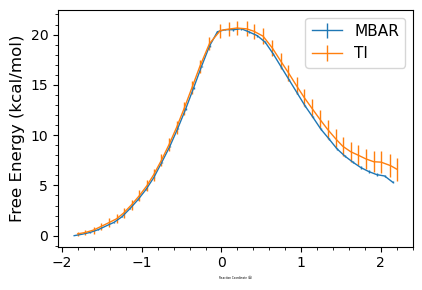

In [5]:
# Comparing PMFs from TI and MBAR

pmf_mbar = np.loadtxt("../mbar/freefile_mbar_allstep6") # PMF from MBAR
pmf_total, pmf_total_std, rc = get_pmf(qmmm_total_forces, qm_pos)
rs_bin = np.argmin(pmf_total[:10]) # Bin index of the reactant state
ts_bin = np.argmax(pmf_total) # Bin index of the transition state

fig, ax = plt.subplots(figsize=(4.33, 3))

ax.set_xlabel("Reaction Coordinate (Å)", size=2)
ax.set_ylabel("Free Energy (kcal/mol)", size=12)
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

# ax.errorbar(pmf_mbar[0], pmf_mbar[1], yerr=pmf_mbar[2], linewidth=1, label="MBAR")
ax.errorbar(pmf_mbar[:,0], pmf_mbar[:,1] - pmf_mbar[:10,1].min(), yerr=pmf_mbar[:,2], linewidth=1, label="MBAR")
ax.errorbar(rc[1:], pmf_total, yerr=pmf_total_std, linewidth=1, label="TI")

ax.legend(fontsize=11)
fig.tight_layout()

<Figure size 1299x900 with 0 Axes>

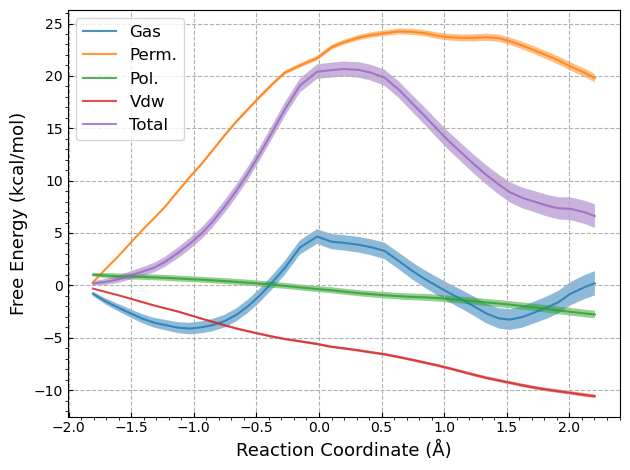

In [29]:
# Decomposition of the free energy profile by energy components

plot_pmf(force_list=[gas_qm_forces, perm_forces, pol_forces, vdw_forces, qmmm_total_forces],
         position=qm_pos,
         labels=["Gas", "Perm.", "Pol.", "Vdw", "Total"])


# plt.xticks(ticks=np.arange(-2.5,2.5,0.5), fontsize=8)
# plt.yticks(ticks=np.arange(-15,30,5), fontsize=8)
plt.grid(linestyle='--')
plt.tick_params(axis='both', direction='in')
plt.legend(fontsize=12)
plt.tight_layout()

plt.savefig('decomp-energy.pdf',bbox_inches='tight',dpi=300)

<Figure size 1299x900 with 0 Axes>

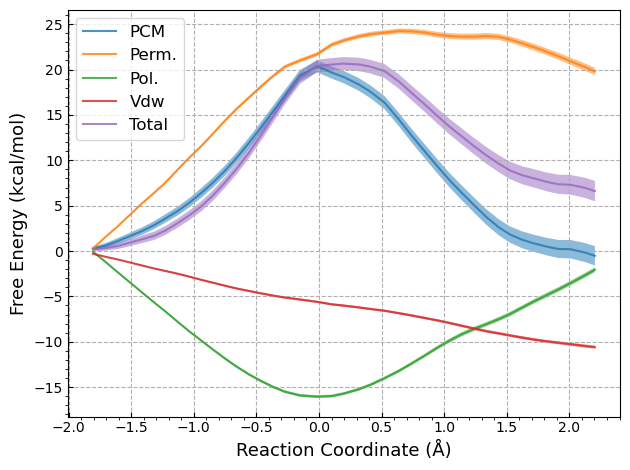

In [31]:
# Decomposition of the free energy profile by energy components

elec2_forces = qmmm_qm_forces - pcm_qm_forces # Electrostatic forces
perm2_forces = gas_res_forces.sum(axis=-1) # Permanent electrostatic forces
pol2_forces = elec2_forces - perm2_forces # Polarization forces
vdw2_forces = vdw_res_forces.sum(axis=-1) # van der Waals forces
qmmm2_total_forces = qmmm_qm_forces + vdw2_forces # Total forces in QM/MM

elec2_res_forces = 0.5 * (qmmm_res_forces + gas_res_forces) # Electrostatic forces from the residues
pol2_res_forces = 0.5 * (qmmm_res_forces - gas_res_forces) # Polarization forces from the residues
total2_res_forces = elec2_res_forces + vdw_res_forces # Total forces from the residues


plot_pmf(force_list=[pcm_qm_forces, perm2_forces, pol2_forces, vdw2_forces, qmmm2_total_forces],
         position=qm_pos,
         labels=["PCM", "Perm.", "Pol.", "Vdw", "Total"])

# plt.xticks(ticks=np.arange(-2.5,2.5,0.5), fontsize=8)
# plt.yticks(ticks=np.arange(-15,30,5), fontsize=8)
plt.grid(linestyle='--')
plt.tick_params(axis='both', direction='in')
plt.legend(fontsize=12)
plt.tight_layout()

plt.savefig('decomp-energy-pcm.pdf',bbox_inches='tight',dpi=300)

In [35]:
# Calculate barrier changes for each residue

total_pmf = get_pmf(qmmm_total_forces, qm_pos)[0]
rs_bin = total_pmf[:10].argmin()
ts_bin = total_pmf.argmax()

num_prot_res = len(res_names)

barrier_perm_res = np.zeros((2, num_prot_res))
barrier_pol_res = np.zeros((2, num_prot_res))
barrier_vdw_res = np.zeros((2, num_prot_res))
barrier_total_res = np.zeros((2, num_prot_res))

for i in range(num_prot_res):
    barrier_perm_res[:, i] = get_barrier(gas_res_forces[..., i], qm_pos, rs_bin, ts_bin)
    barrier_pol_res[:, i] = get_barrier(pol_res_forces[..., i], qm_pos, rs_bin, ts_bin)
    barrier_vdw_res[:, i] = get_barrier(vdw_res_forces[..., i], qm_pos, rs_bin, ts_bin)
    barrier_total_res[:, i] = get_barrier(total_res_forces[..., i], qm_pos, rs_bin, ts_bin)

In [36]:
# Put the barrier changes into a DataFrame for easy exploration

prot_name = "WT"

multicol = pd.MultiIndex.from_tuples(
    [
        (prot_name, 'Perm.'), (prot_name, 'Perm. Std.'),
        (prot_name, 'Pol.'), (prot_name, 'Pol. Std.'),
        (prot_name, 'VdW'), (prot_name, 'VdW Std.'),
        (prot_name, 'Total'), (prot_name, 'Total Std.'),
     ])

df = pd.DataFrame(data=np.vstack(
    (
        barrier_perm_res[0], barrier_perm_res[1],
        barrier_pol_res[0], barrier_pol_res[1],
        barrier_vdw_res[0], barrier_vdw_res[1],
        barrier_total_res[0], barrier_total_res[1],
    )).T,
    columns=multicol)

df.index = res_names

# Uncomment to save the table
df.to_pickle("barrier_res_table.pkl")

In [42]:
# Tabulate residues with contributions to the free energy barrier by more than 0.3 kcal/mol

df[abs(df[(prot_name, 'Total')]) > 0.3].sort_values(by=(prot_name, 'Total'))

WT                                                         \
                 Perm. Perm. Std.      Pol. Pol. Std.       VdW      VdW Std.   
Far         -17.530294   0.332708  1.051758  0.209738  0.000000  0.000000e+00   
DNA-Dc1500  -14.835962   0.067863  0.072455  0.041415  0.373900  6.465381e-03   
Prot-Asp850 -10.466881   0.030768  1.377465  0.016177 -0.000012  1.027154e-06   
Prot-Asp839  -9.499212   0.036266  1.118534  0.017577 -0.035290  2.368607e-04   
Prot-Glu809  -7.322502   0.025658 -0.184269  0.027055  0.000803  3.112024e-05   
...                ...        ...       ...       ...       ...           ...   
DNA-Dt1499    7.939336   0.040951 -0.718209  0.025985  0.001358  1.720640e-05   
Prot-Asn863   7.891991   0.028820 -0.060531  0.019721 -0.000016  7.547353e-07   
Prot-Lys855  10.527798   0.030103 -1.011919  0.016114 -0.002019  2.439425e-05   
Prot-Hie840  10.871864   0.048609 -0.913794  0.030909 -0.020945  1.631127e-04   
Near         34.399006   0.417205 -0.283867  0.258207 -5.003879  1.207808e-01   

                                   
                 Total Total Std.  
Far         -16.478536   0.224615  
DNA-Dc1500  -14.389607   0.056073  
Prot-Asp850  -9.089429   0.020327  
Prot-Asp839  -8.415968   0.028284  
Prot-Glu809  -7.505968   0.028032  
...                ...        ...  
DNA-Dt1499    7.222485   0.034450  
Prot-Asn863   7.831445   0.021017  
Prot-Lys855   9.513861   0.020510  
Prot-Hie840   9.937125   0.036926  
Near         29.111260   0.314442  

[335 rows x 8 columns]

In [52]:
import pickle

with open('barrier_res_table.pkl', 'rb') as f:
    data = pickle.load(f)
    
data['WT']['Total']

Prot-Asp2      -0.009381
Prot-Lys3       0.128690
Prot-Lys4       0.203683
Prot-Tyr5      -0.003622
Prot-Ser6       0.004048
                 ...    
DNA-Dc1512     -0.590477
DNA-Dg1513     -0.463034
DNA-Da31514    -0.414910
Near           29.111260
Far           -16.478536
Name: Total, Length: 1514, dtype: float64

In [41]:
from tabulate import tabulate
df3 = df[abs(df[(prot_name, 'Total')]) > 1].sort_values(by=(prot_name, 'Total'))

print(tabulate(df3, tablefmt="latex_booktabs", floatfmt=".2f"))

\begin{tabular}{lrrrrrrrr}
\toprule
 Far          & -17.53 & 0.33 &  1.05 & 0.21 &  0.00 & 0.00 & -16.48 & 0.22 \\
 DNA-Dc1500   & -14.84 & 0.07 &  0.07 & 0.04 &  0.37 & 0.01 & -14.39 & 0.06 \\
 Prot-Asp850  & -10.47 & 0.03 &  1.38 & 0.02 & -0.00 & 0.00 &  -9.09 & 0.02 \\
 Prot-Asp839  &  -9.50 & 0.04 &  1.12 & 0.02 & -0.04 & 0.00 &  -8.42 & 0.03 \\
 Prot-Glu809  &  -7.32 & 0.03 & -0.18 & 0.03 &  0.00 & 0.00 &  -7.51 & 0.03 \\
 Prot-Arg864  &  -6.60 & 0.04 &  0.33 & 0.02 &  0.00 & 0.00 &  -6.27 & 0.04 \\
 Prot-Val838  &  -7.34 & 0.06 &  2.05 & 0.03 & -0.95 & 0.04 &  -6.24 & 0.07 \\
 Prot-Asp849  &  -6.68 & 0.03 &  0.98 & 0.01 &  0.00 & 0.00 &  -5.70 & 0.02 \\
 Prot-Lys866  &  -6.39 & 0.05 &  1.01 & 0.03 &  0.00 & 0.00 &  -5.38 & 0.04 \\
 RNA-A1381    &  -4.34 & 0.01 &  0.48 & 0.01 &  0.00 & 0.00 &  -3.86 & 0.01 \\
 RNA-G1380    &  -3.65 & 0.01 &  0.44 & 0.01 &  0.00 & 0.00 &  -3.21 & 0.01 \\
 RNA-A1379    &  -3.50 & 0.01 &  0.34 & 0.00 &  0.00 & 0.00 &  -3.16 & 0.01 \\
 Prot-Glu60   & 

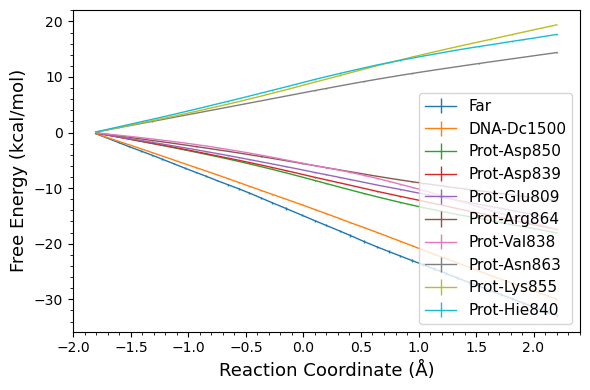

In [40]:
# Plot the free energy profile for the residues with the largest contributions to the barrier

res_idx = np.concatenate((np.argsort(barrier_total_res[0])[:7], np.argsort(barrier_total_res[0])[-4:-1]))
plot_pmf(force_list=[total_res_forces[..., i] for i in res_idx],
         position=qm_pos,
         labels=res_names[res_idx])

In [11]:
from scipy.interpolate import CubicSpline
from scipy.integrate import quad
from scipy.optimize import fsolve

In [12]:
def fit_cubic_spline(images, t=None):
    """Fit a cubic spline to a set of images"""
    if t is None:
        image_diff = np.diff(images, axis=0)
        dist = np.append([0], np.sqrt((image_diff**2).sum(axis=1)))
        t = np.cumsum(dist)
        t /= t[-1]
        
    return CubicSpline(t, images)


def get_arc_length(spline, t0=0.0, t1=1.0):
    """Calculate the arc length of a cubic spline"""
    dt = lambda t: spline.derivative()(t)
    return quad(lambda t: np.sqrt((dt(t)**2).sum(axis=0)), t0, t1, epsabs=1.0e-02)[0]


def get_length_diff(t1, spline, length):
    """Calculate the difference between the arc length of a cubic spline and a given length"""
    return get_arc_length(spline, t0=0.0, t1=t1) - length


def parameterize_pathway_cubic_spline(images, t=None, n_images=None):
    """Parameterize a pathway using a cubic spline"""
    if n_images is None:
        n_images = len(images)
        
    spline = fit_cubic_spline(images, t)
    arc_length = get_arc_length(spline)
    cum_equil_length = np.linspace(0, arc_length, n_images)
    
    new_t = np.zeros(n_images)
    for i, length in enumerate(cum_equil_length):
        new_t[i] = fsolve(get_length_diff, i / (n_images - 1), (spline, length), xtol=1.0e-02)
    
    return spline(new_t)

In [13]:
# Calculate the gradient of the collective variables with respect to the reaction coordinate

d1_mean = np.linalg.norm(qm_pos[:, :, 2] - qm_pos[:, :, 3], axis=-1).mean(axis=1)
d2_mean = np.linalg.norm(qm_pos[:, :, 0] - qm_pos[:, :, 1], axis=-1).mean(axis=1)
d1_std = np.linalg.norm(qm_pos[:, :, 2] - qm_pos[:, :, 3], axis=-1).std(axis=1)
d2_std = np.linalg.norm(qm_pos[:, :, 0] - qm_pos[:, :, 1], axis=-1).std(axis=1)

spline = fit_cubic_spline(np.column_stack((d1_mean, d2_mean)))

grad = spline.derivative()
grad1 = grad(spline.x)[:, 0]
grad2 = -grad(spline.x)[:, 1]

d1 = grad1 / (grad1 + grad2)
d2 = grad2 / (grad1 + grad2)

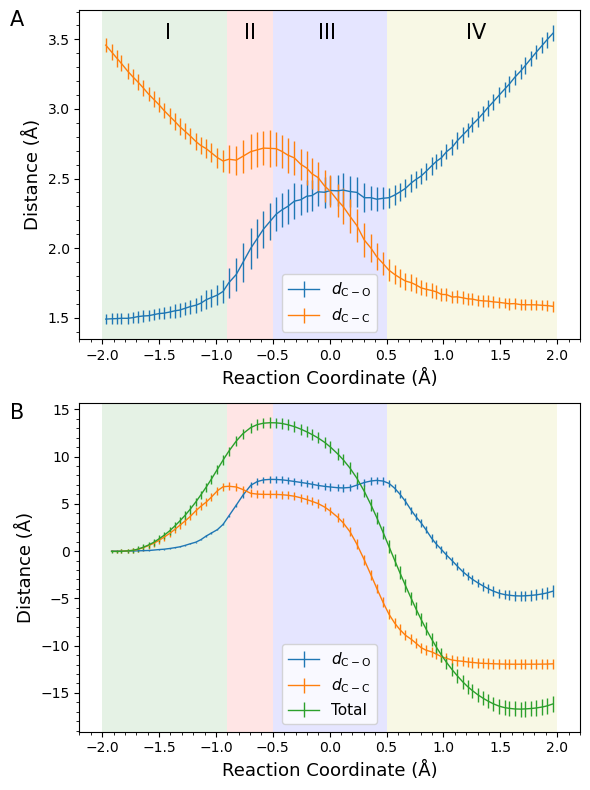

In [14]:
# Plot the decomposition of the reaction path and the free energy profile by collective variables

pmf_total1, pmf_total_std1, rc = get_pmf(qmmm_total_forces * d1[:, None, None, None], qm_pos)
pmf_total2, pmf_total_std2, rc = get_pmf(qmmm_total_forces * d2[:, None, None, None], qm_pos)

fig, ax = plt.subplots(2, 1, figsize=(6, 8))

for a in ax:
    a.set_xlabel("Reaction Coordinate (Å)", size=13)
    a.set_ylabel("Distance (Å)", size=13)
    a.xaxis.set_minor_locator(AutoMinorLocator(5))
    a.yaxis.set_minor_locator(AutoMinorLocator(5))

    a.axvspan(-2, -0.9, facecolor='g', alpha=0.1)
    a.axvspan(-0.9, -0.5, facecolor='r', alpha=0.1)
    a.axvspan(-0.5, 0.5, facecolor='b', alpha=0.1)
    a.axvspan(0.5, 2.0, facecolor='y', alpha=0.1)

ax[0].text(-1.45, 3.5, 'I', fontsize=15, color='black')
ax[0].text(-0.75, 3.5, 'II', fontsize=15, color='black')
ax[0].text(-0.1, 3.5, 'III', fontsize=15, color='black')
ax[0].text(1.2, 3.5, 'IV', fontsize=15, color='black')

ax[0].errorbar(rc, d1_mean, yerr=d1_std, linewidth=1, label="$d_\mathrm{C-O}$")
ax[0].errorbar(rc, d2_mean, yerr=d2_std, linewidth=1, label="$d_\mathrm{C-C}$")
ax[0].legend(fontsize=11)

ax[0].annotate('A', xy=(0, 1), xycoords='axes fraction', fontsize=15,
                              xytext=(-50, 0), textcoords='offset points',
                              ha='left', va='top')

ax[1].errorbar(rc[1:], pmf_total1, yerr=pmf_total_std1, linewidth=1, label="$d_\mathrm{C-O}$")
ax[1].errorbar(rc[1:], pmf_total2 , yerr=pmf_total_std2, linewidth=1, label="$d_\mathrm{C-C}$")
ax[1].errorbar(rc[1:], pmf_total, yerr=pmf_total_std, linewidth=1, label="Total")
ax[1].legend(fontsize=11)

ax[1].annotate('B', xy=(0, 1), xycoords='axes fraction', fontsize=15,
                              xytext=(-50, 0), textcoords='offset points',
                              ha='left', va='top')

fig.tight_layout()

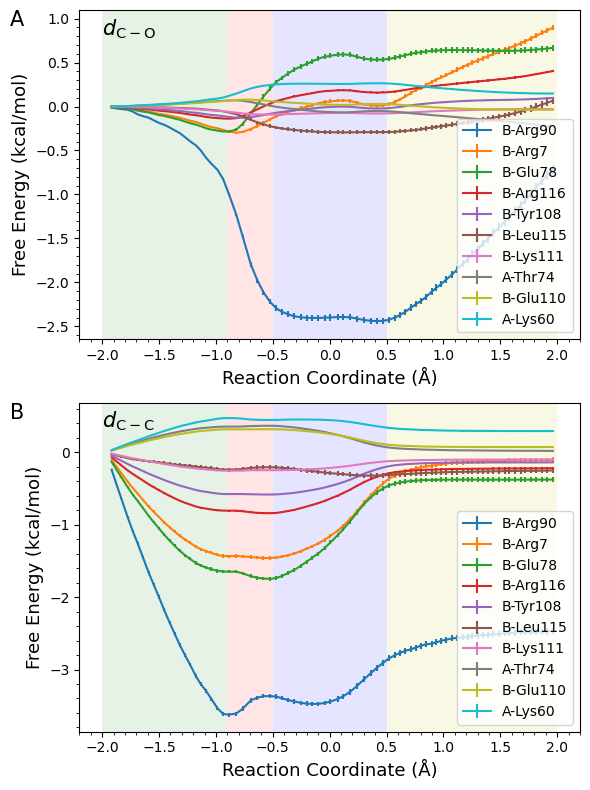

In [15]:
# Plot the decomposition of the free energy profile by collective variables and residues

fig, ax = plt.subplots(2, 1, figsize=(6, 8))

for a in ax:
    a.set_xlabel("Reaction Coordinate (Å)", size=13)
    a.set_ylabel("Free Energy (kcal/mol)", size=13)
    a.xaxis.set_minor_locator(AutoMinorLocator(5))
    a.yaxis.set_minor_locator(AutoMinorLocator(5))

    a.axvspan(-2, -0.9, facecolor='g', alpha=0.1)
    a.axvspan(-0.9, -0.5, facecolor='r', alpha=0.1)
    a.axvspan(-0.5, 0.5, facecolor='b', alpha=0.1)
    a.axvspan(0.5, 2.0, facecolor='y', alpha=0.1)

for i in res_idx:
    pmf_total_res1, pmf_total_res_std1, rc= get_pmf(total_res_forces[..., i] * d1[:, None, None, None], qm_pos)
    pmf_total_res2, pmf_total_res_std2, rc = get_pmf(total_res_forces[..., i] * d2[:, None, None, None], qm_pos)

    ax[0].errorbar(rc[1:], pmf_total_res1, yerr=pmf_total_res_std1, label=res_names[i])
    ax[1].errorbar(rc[1:], pmf_total_res2, yerr=pmf_total_res_std2, label=res_names[i])

ax[0].annotate('A', xy=(0, 1), xycoords='axes fraction', fontsize=15,
                              xytext=(-50, 0), textcoords='offset points',
                              ha='left', va='top')
ax[0].annotate("$d_\mathrm{C-O}$", xy=(0, 1), xycoords='axes fraction', fontsize=15,
                              xytext=(16, -5), textcoords='offset points',
                              ha='left', va='top')

ax[1].annotate('B', xy=(0, 1), xycoords='axes fraction', fontsize=15,
                              xytext=(-50, 0), textcoords='offset points',
                              ha='left', va='top')
ax[1].annotate("$d_\mathrm{C-C}$", xy=(0, 1), xycoords='axes fraction', fontsize=15,
                              xytext=(16, -5), textcoords='offset points',
                              ha='left', va='top')
ax[0].legend(loc=4)
ax[1].legend(loc=4)
fig.tight_layout()